<a href="https://colab.research.google.com/github/Rafhaeloktafandhi/Analisis-runtun-waktu/blob/main/Praktikum_ARW_2_SARIMA_mahasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Runtun Waktu

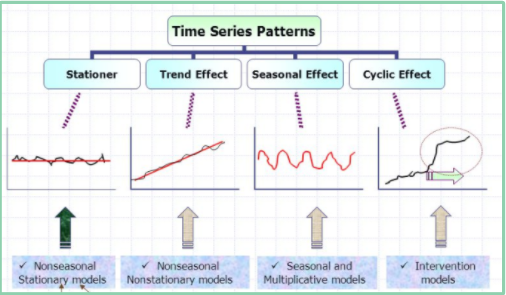


#Persiapan Library & Dataset

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.7 MB/s eta 0:00:00


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
plt.rcParams['figure.figsize'] = 12, 6            #agar semua plot ukurannya sama
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.arima import auto_arima
from scipy import stats
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from dateutil.relativedelta import relativedelta
from pandas import Timestamp

In [3]:
#Download data
!wget https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv

--2026-06-19 01:09:41--  https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1746 (1.7K) [text/plain]
Saving to: ‘AirPassengers.csv’

AirPassengers.csv   100%[===================>]   1.71K  --.-KB/s    in 0s      

2026-06-19 01:09:42 (28.1 MB/s) - ‘AirPassengers.csv’ saved [1746/1746]



In [4]:
#Load data
data_passenger = pd.read_csv('AirPassengers.csv')
data_passenger

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


# Preprocessing

In [5]:
#Mengubah tanggal menjadi index
data_passenger['Month']=pd.to_datetime(data_passenger['Month'])
data_passenger.set_index('Month', inplace=True)
#check datatype of index
data_passenger.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [6]:
#Menentukan data training dan testing

train_size = int(len(data_passenger)*0.7)         #70% data pertama menjadi data training
train, test = data_passenger[:train_size], data_passenger[train_size:]

# Visualisasikan data & Uji Stasioner
Uji stasioner dengan Dickey-Fuller test

Ho : data tidak stasioner

H1 : data stasioner

Karena cukup sering digunakan, jadi kita buat fungsinya dulu


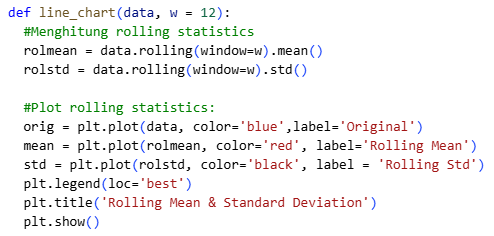

In [7]:
def line_chart(data, w = 12):
  #Menghitung rolling statistics
  rolmean = data.rolling(window=w).mean()
  rolstd = data.rolling(window=w).std()  #Plot rolling statistics:
  orig = plt.plot(data, color='blue',label='Original')
  mean = plt.plot(rolmean, color='red', label='Rolling Mean')
  std = plt.plot(rolstd, color='black', label = 'Rolling Std')
  plt.legend(loc='best')
  plt.title('Rolling Mean & Standard Deviation')
  plt.show()

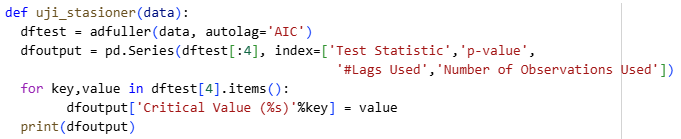

In [18]:
def uji_stasioner(data):
  dftest = adfuller(data, autolag='AIC')
  dfoutput = pd.Series(dftest[:4], index=['Test Statistic','p-value', '#Lags Used','Number of Observations Used'])
  for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
  print(dfoutput)

## Data Asli

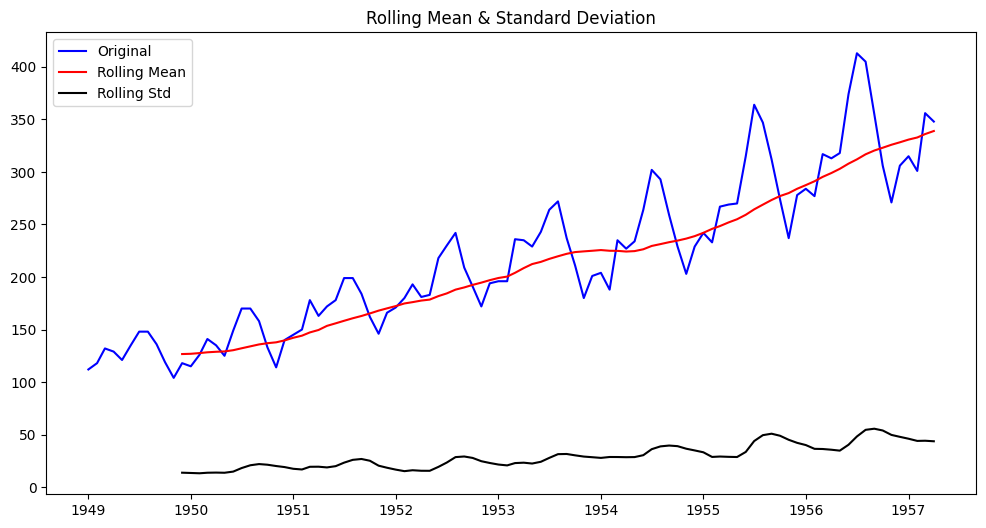

Test Statistic                  1.509804
p-value                         0.997560
#Lags Used                     12.000000
Number of Observations Used    87.000000
Critical Value (1%)            -3.507853
Critical Value (5%)            -2.895382
Critical Value (10%)           -2.584824
dtype: float64


In [19]:
#visualisasi
line_chart(train)

#uji stasioner
uji_stasioner(train)

Baik standard deviasi dan rata-rata berubah seiring waktu. Sehingga datanya tidak stasioner dan juga tidak mengikuti pola trend. Namun terlihat perubahan di tiap interval tertentu sehingga ada kemungkinan data memiliki pola musiman.

Menurut uji Dickey-Fuller, p-value = 0.99 > 0.05, sehingga kalo menggunakan CI 95% Ho gagal ditolak, data tidak stasioner. Nah, jika kita tetap ingin menggunakan model ARIMA, kita harus melakukan transformasi atau differencing.

## Data differencing sekali

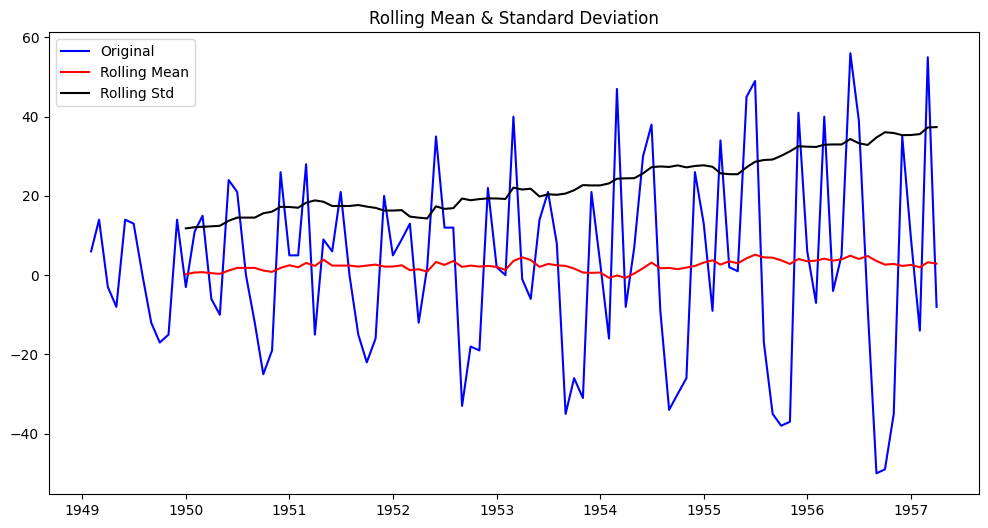

Test Statistic                 -2.180602
p-value                         0.213361
#Lags Used                     12.000000
Number of Observations Used    86.000000
Critical Value (1%)            -3.508783
Critical Value (5%)            -2.895784
Critical Value (10%)           -2.585038
dtype: float64


In [20]:
#Lakukan differencing sekali:
train_diff_1 = train.diff(1).dropna()

#line chart
line_chart(train_diff_1)

#uji stasioner
uji_stasioner(train_diff_1)

Datanya masih tidak stasioner, sekarang kita coba lagi differencing sekali lagi

## Data differencing 2

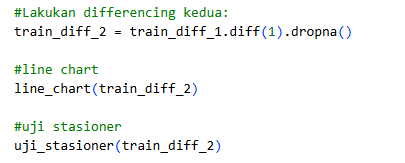

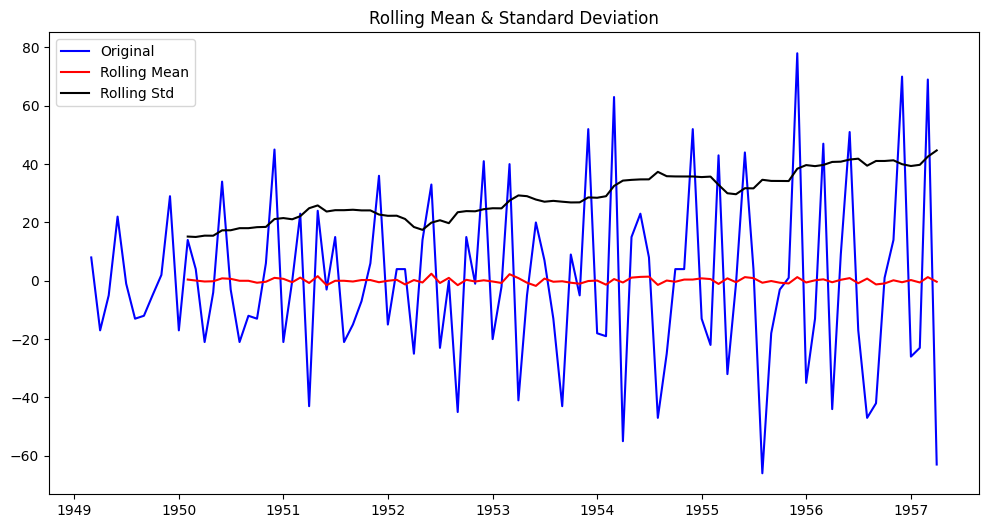

Test Statistic                -1.217795e+01
p-value                        1.372387e-22
#Lags Used                     1.100000e+01
Number of Observations Used    8.600000e+01
Critical Value (1%)           -3.508783e+00
Critical Value (5%)           -2.895784e+00
Critical Value (10%)          -2.585038e+00
dtype: float64


In [21]:
#Lakukan differencing kedua:
train_diff_2 = train_diff_1.diff(1).dropna()

#line chart
line_chart(train_diff_2)

#uji stasioner
uji_stasioner(train_diff_2)

Datanya masih tidak stasioner, sekarang kita coba identifikasi efek musimannya

# Identifikasi Pola Musiman

Kita akan melakukan plot ACF & PACF dan Dekomposisi komponen data. Karena akan cukup banyak mengulang, kita buatkan fungsinya dulu. Untuk dekomposisi komponen data sendiri terdiri dari 2 tipe:

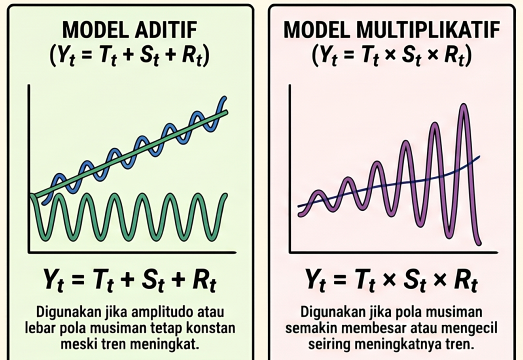

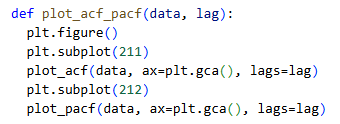

In [22]:
def plot_acf_pacf(data, lag):
  plt.figure()
  plt.subplot(211)
  plot_acf(data, ax=plt.gca(), lags=lag)
  plt.subplot(212)
  plot_pacf(data, ax=plt.gca(), lags=lag)

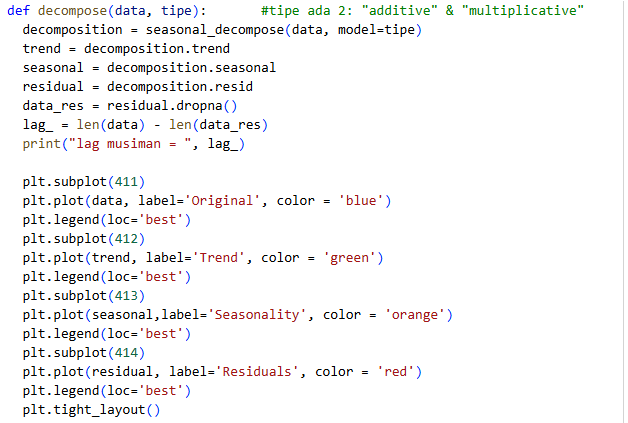

In [26]:
def decompose(data, tipe):       #tipe ada 2: "additive" & "multiplicative"
  decomposition = seasonal_decompose(data, model=tipe)
  trend = decomposition.trend
  seasonal = decomposition.seasonal
  residual = decomposition.resid
  data_res = residual.dropna()
  lag_ = len(data) - len(data_res)
  print("lag musiman = ", lag_)


  plt.subplot(411)
  plt.plot(data, label='Original', color = 'blue')
  plt.legend(loc='best')
  plt.subplot(412)
  plt.plot(trend, label='seasonality', color = 'green')
  plt.plot(seasonal, label='trend', color = 'gray')
  plt.legend(loc='best')
  plt.subplot(413)
  plt.plot(residual, label='Residuals', color = 'gray')
  plt.legend(loc='best')
  plt.subplot(414)
  plt.plot(data_res, label='Residuals', color = 'red')
  plt.legend(loc='best')
  plt.tight_layout()

## Plot ACF & PACF data asli

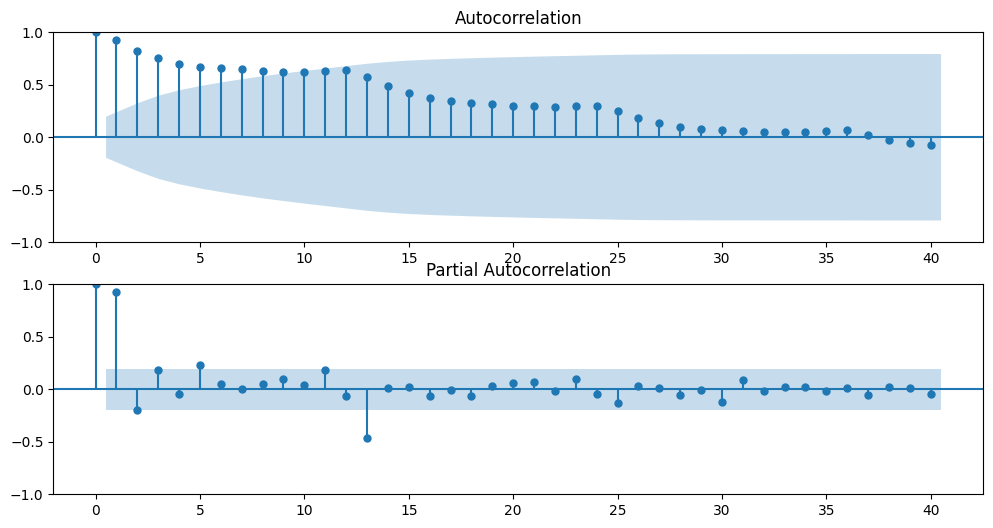

In [27]:
#Plot ACF dan PACF data asli
plot_acf_pacf(train, lag=40)

Terlihat pola ACF tailing off dan terlihat pola berulang per 12 lag. Sehingga ada kemungkinan terdapat pola musiman dengan lag = 12. Sekarang kita coba identifikasi menggunakan dekomposisi komponen. Karena berdasarkan line chart terlihat

## Dekomposisi Komponen Data Asli
Karena hasil visualisasi line graph menunjukkan pola musiman membesar seiring trend, maka kita gunakan dekomposisi "multiplicative"

lag musiman =  12


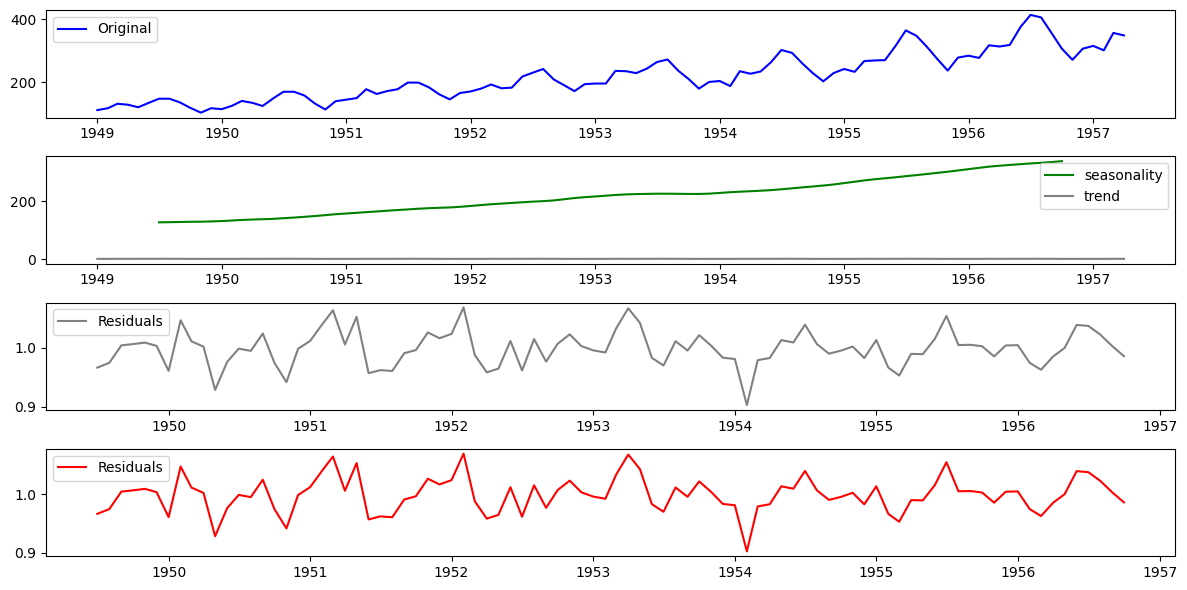

In [28]:
decompose(train, tipe="multiplicative")

Terlihat datanya memiliki pola trend dan pola musiman. Lalu, data residualnya terlihat lebih stabil di sekitar rata-rata yang menunjukkan stasioneritas. Namun untuk lebih meyakinkan, kita cek apakah data setelah differencing 12 akan membuat data menjadi stasioner

## Uji stasioner setelah cek musiman data asli

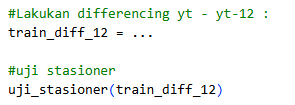

In [29]:
#Lakukan differencing yt - yt-12 :
train_diff_12 = train.diff(12).dropna()

#uji stasioner
uji_stasioner(train_diff_12)

Test Statistic                 -2.739251
p-value                         0.067489
#Lags Used                      1.000000
Number of Observations Used    86.000000
Critical Value (1%)            -3.508783
Critical Value (5%)            -2.895784
Critical Value (10%)           -2.585038
dtype: float64


Kalo menggunakan CI 90% datanya sudah stasioner, tapi karena kita menggunakan CI 95%, datanya belum stasioner. Sekarang kita coba menggunakan data differencing sekali.

## Plot ACF & PACF data differencing sekali (d=1)
masukkan fungsi plot acf & pacf untuk data train_diff_1

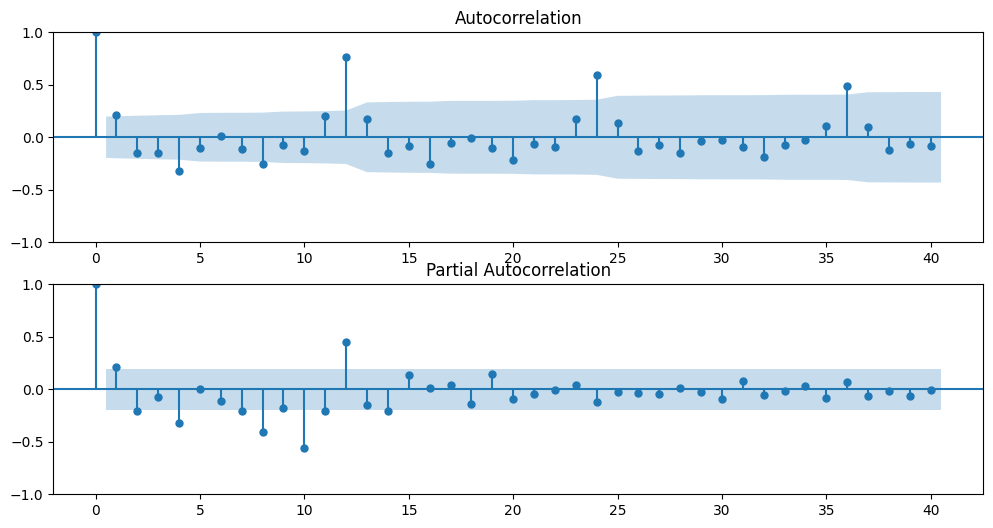

In [31]:
plot_acf_pacf(train_diff_1, lag=40)

Terlihat pola ACF tailing off dan terlihat pola berulang per 12 lag, tapi terlihat juga nilai ACF mencapai max/min tiap 4 lag, artinya parameter s-nya bisa saja 12 atau 4. Coba cek lagi decompositionnya

## Dekomposisi Komponen data differencing sekali (d=1)
masukkan fungsi dekomposisi untuk data train_diff_1

lag musiman =  12


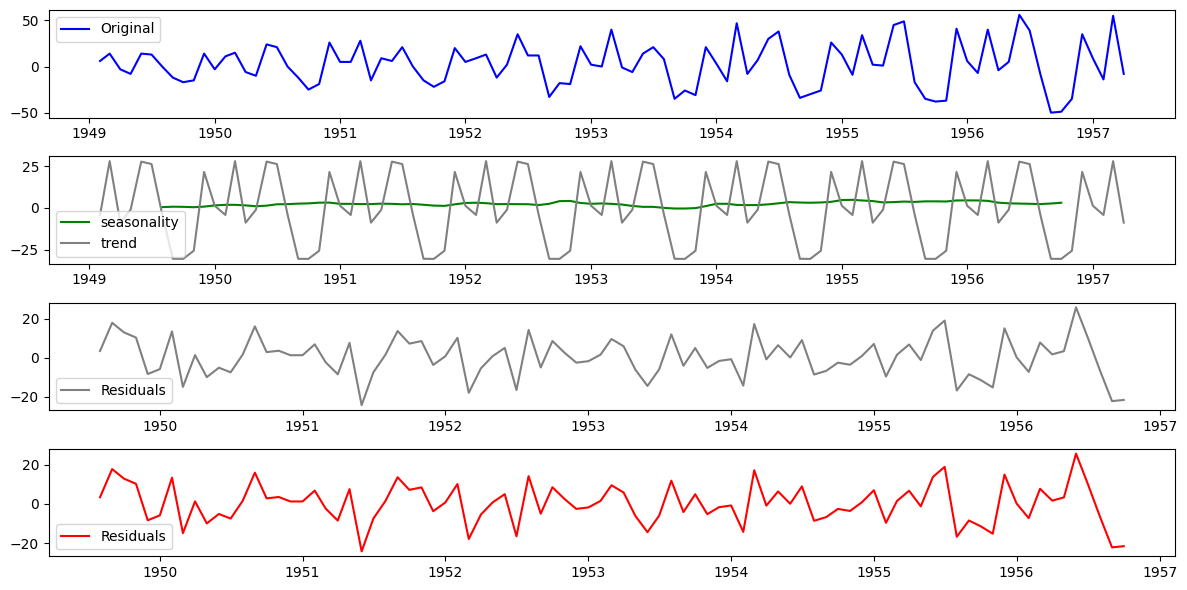

In [33]:
decompose(train_diff_1, tipe="additive")

Karena sudah terlihat ada sisi musimannya, sekarang kita cek stasioneritasnya

## Uji stasioner setelah cek musiman data differencing sekali (d=1)

In [34]:
#Lakukan differencing 12 dari train_diff_1:
train_diff_1_12 = train_diff_1.diff(12).dropna()

#uji stasioner
uji_stasioner(train_diff_1_12)

Test Statistic                -1.218699e+01
p-value                        1.311831e-22
#Lags Used                     0.000000e+00
Number of Observations Used    8.600000e+01
Critical Value (1%)           -3.508783e+00
Critical Value (5%)           -2.895784e+00
Critical Value (10%)          -2.585038e+00
dtype: float64


Terlihat p-value = 1.311831e-22 < 0.05, akhirnya datanya stasioner

# Training model


## Plot ACF & PACF data yang sudah stasioner
plot ACF & PACF data train_diff_1_12

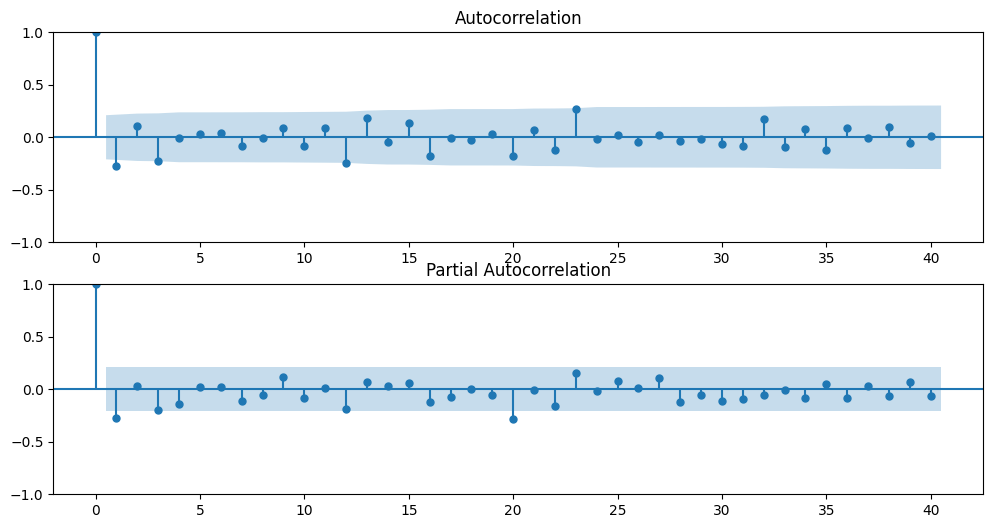

In [35]:
plot_acf_pacf(train_diff_1_12, lag=40)

Terlihat bahwa :     
1. Grafik ACF mengalami cut-off tepat setelah lag 1, maka q = 1
2. Garis vertikal ACF memanjang saat lag=12 (kelipatan 1 dari lag s-nya) dan kembali masuk area biru saat lag=24, artinya Q = 1
3. Grafik ACF mengalami dies down (berosilasi), sehingga kemungkinan besar p=0.
4. Karena ACF berosilasi, kemungkinan P juga 0, tapi karena terlihat garis vertikal PACF memanjang saat lag=12 (kelipatan 1 dari lag s-nya) dan kembali masuk area biru saat lag=24, ada kemungkinan P = 1

Karena sebelumnya data di-differencing sekali, lalu differencing 12 (mengikuti pola musiman), maka modelnya menjadi :     

$$\text{SARIMA}(0, 1, 1)(0, 1, 1)_{12}$$


## Training

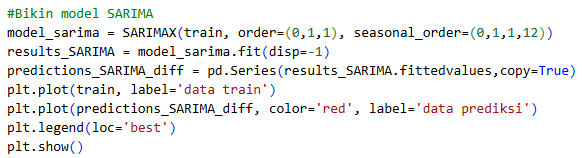

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


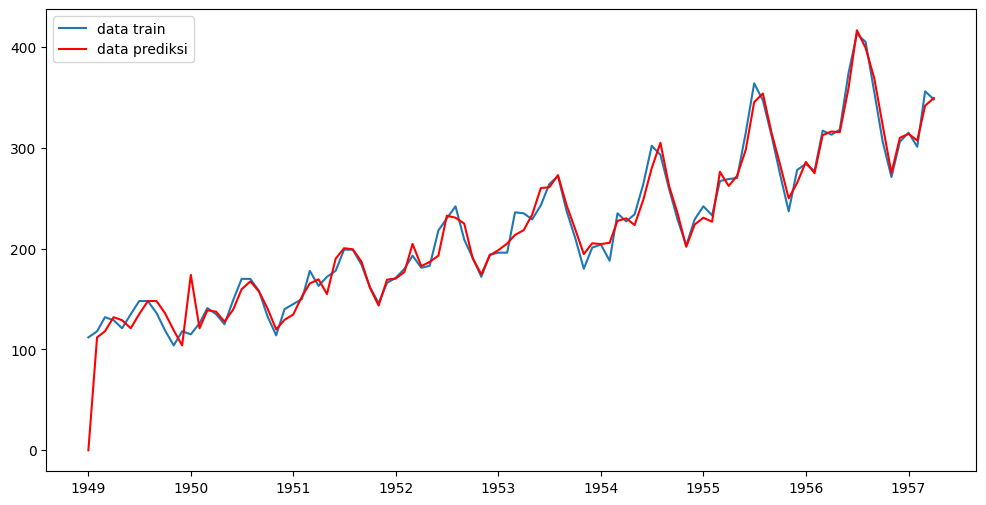

In [ ]:
#Bikin model SARIMA
model_sarima = ...
results_SARIMA = ...
predictions_SARIMA_diff = ...
plt.plot...
plt.plot...
plt.legend(loc='best')
plt.show()

In [ ]:
print(results_SARIMA.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        #Passengers   No. Observations:                  100
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -319.367
Date:                            Mon, 15 Jun 2026   AIC                            644.733
Time:                                    03:56:55   BIC                            652.131
Sample:                                01-01-1949   HQIC                           647.712
                                     - 04-01-1957                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2416      0.099     -2.435      0.015      -0.436      -0.047
ma.S.L12      -0.1934      0.103   

## Evaluasi Testing

mse =  682.1398250790946
rmse =  26.117806666699533
mae =  21.2668945075216
mape =  0.050816360626485174


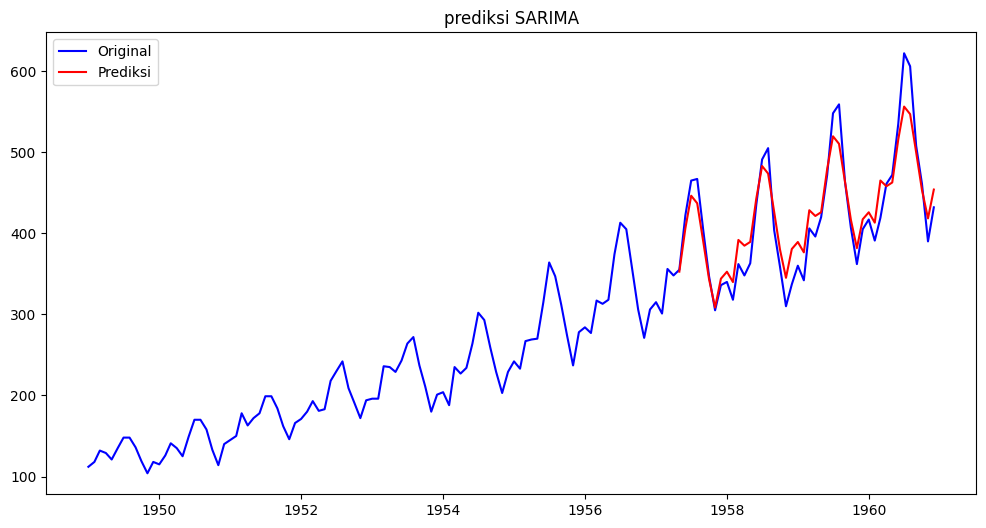

In [ ]:
pred = results_SARIMA.predict(start=len(train), end=len(data_passenger) - 1)  #hitung prediksi dari indeks testingnya saja
pred.index = test.index  #menyamakan indeks

print('mse = ', mean_squared_error(test, pred))
print('rmse = ', root_mean_squared_error(test, pred))
print('mae = ', mean_absolute_error(test, pred))
print('mape = ', mean_absolute_percentage_error(test, pred))

orig = plt.plot(data_passenger, color='blue',label='Original')
prediksi = plt.plot(pred, color='red',label='Prediksi')
plt.legend(loc='best')
plt.title('prediksi SARIMA')
plt.show()

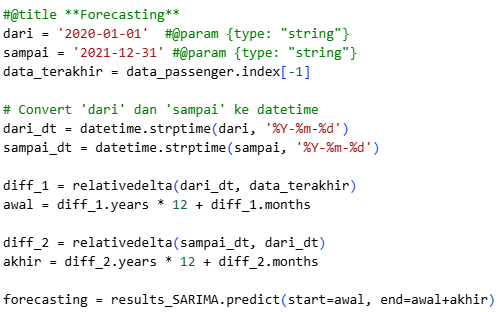

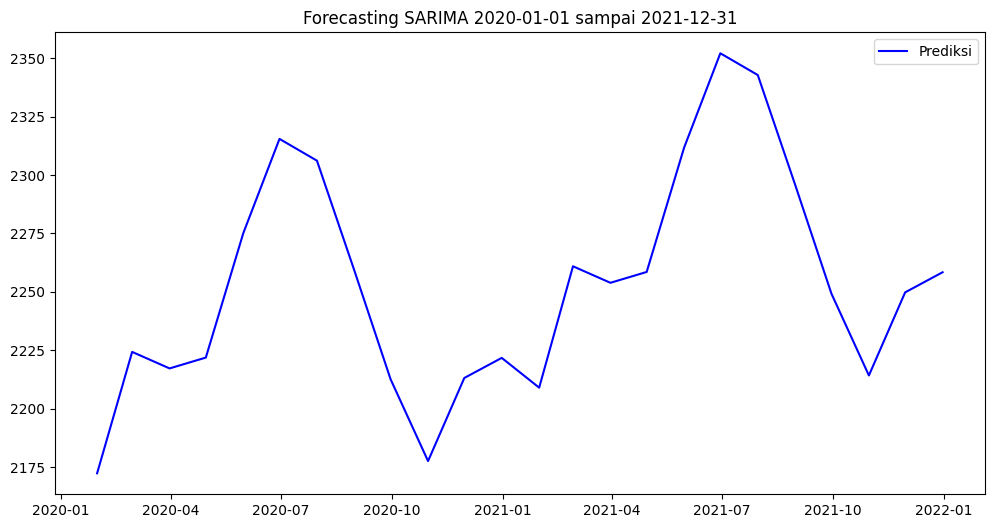

,predicted_mean
2020-01-31,2172.308649
2020-02-29,2224.261147
2020-03-31,2217.193479
2020-04-30,2221.830701
2020-05-31,2275.049248
2020-06-30,2315.438526
2020-07-31,2306.122559
2020-08-31,2259.061243
2020-09-30,2212.526541
2020-10-31,2177.532452


In [ ]:
#@title
dari = ...
sampai = ...
data_terakhir = ...

# Convert 'dari' dan 'sampai' ke datetime
dari_dt = ...
sampai_dt = ...

diff_1 = ...
awal = ...

diff_2 = ...
akhir = ...

forecasting = ...
forecasting.index = pd.date_range(start=dari_dt, periods=akhir+1, freq='ME')
plt.plot(forecasting, color='blue',label='Prediksi')
plt.legend(loc='best')
plt.title('Forecasting SARIMA '+dari+" sampai "+sampai)
plt.show()

forecasting

# Latihan
Lakukan pemodelan SARIMA, mulai dari memastikan stasioneritas, training, evaluasi hasil prediksi, hingga hasil prediksinya:

*   Kelompok 1 : data aslinya ditransform log, lalu differencing, lalu efek musimannya s=4
*   Kelompok 2 : data aslinya ditransform log, lalu differencing, lalu efek musimannya s=12
*   Kelompok 3 : data aslinya ditransform log, tidak didifferencing, lalu efek musimannya s=4
*   Kelompok 4 : data aslinya ditransform log, tidak didifferencing, lalu efek musimannya s=12
*   Kelompok 5 : data aslinya didifferencing 2x, lalu identifikasi efek musiman yang cocok

Apakah lebih baik dari model sebelumnya?

